<a href="https://colab.research.google.com/github/aadityane93/Toxic_Comments_Sentiment_Analysis/blob/jupyter/3_Binary_label_NN_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Neural Network From Scratch: Clean vs Unclean

This notebook is the binary version of the neural network notebook.

The model predicts only one thing:

- `clean` means the comment has none of the six warning labels.
- `unclean` means the comment has at least one of the six warning labels.

The model output is one number. After sigmoid, that number becomes the probability that the comment is `unclean`.


## Install Modules


## Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


## Load Files And Make Clean/Unclean Labels


In [ ]:
# Load files from the current folder
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
test_labels = pd.read_csv("test_labels.csv")

# Remove rows where comment_text is missing
train_df = train_df.dropna(subset=["comment_text"])
test_df = test_df.dropna(subset=["comment_text"])

# Make sure comment_text is stored as text
train_df["comment_text"] = train_df["comment_text"].astype(str)
test_df["comment_text"] = test_df["comment_text"].astype(str)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test labels shape:", test_labels.shape)

# These are the original six label columns from the dataset
label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

# Count how many of the original labels each comment has
train_df["label_count"] = train_df[label_cols].sum(axis=1)

# unclean = 1 means the comment has at least one original label
train_df["unclean"] = (train_df["label_count"] > 0).astype(int)

# clean = 1 means the comment has no original labels
train_df["clean"] = 1 - train_df["unclean"]

# Show how many comments are clean and unclean
print("Clean comments:", train_df["clean"].sum())
print("Unclean comments:", train_df["unclean"].sum())
print("Comments with more than one original label:", (train_df["label_count"] > 1).sum())


Train shape: (159571, 8)
Test shape: (153164, 2)
Test labels shape: (153164, 7)
Clean comments: 143346
Unclean comments: 16225
Comments with more than one original label: 9865


## Clean Text


In [ ]:
# This function makes text easier for the model to read
def clean_text(text):
    # Convert text to lowercase so Hello and hello are treated the same
    text = text.lower()

    # Keep only letters, numbers, and spaces
    text = re.sub(r"[^a-z0-9 ]", " ", text)

    # Replace repeated spaces with one space
    text = re.sub(r"\s+", " ", text).strip()

    # Return the cleaned comment
    return text


# Clean training comments
train_df["clean_text"] = train_df["comment_text"].apply(clean_text)

# Clean test comments
test_df["clean_text"] = test_df["comment_text"].apply(clean_text)


## Split Training Data


In [ ]:
# Split train.csv into training data and validation data
# stratify keeps a similar clean/unclean ratio in both parts
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["unclean"]
)

# Reset indexes after splitting
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)

# Check split sizes
print("Training data:", train_data.shape)
print("Validation data:", val_data.shape)

# Check clean/unclean balance in both splits
print("Training clean percent:", train_data["clean"].mean() * 100)
print("Training unclean percent:", train_data["unclean"].mean() * 100)
print("Validation clean percent:", val_data["clean"].mean() * 100)
print("Validation unclean percent:", val_data["unclean"].mean() * 100)


Training data: (127656, 12)
Validation data: (31915, 12)
Training clean percent: 89.832048630695
Training unclean percent: 10.167951369305008
Validation clean percent: 89.83236722544258
Validation unclean percent: 10.167632774557418


## Tokenizer


In [ ]:
# This function splits a comment into words
def tokenize(text):
    # Split text by spaces
    return text.split()


## Build Vocabulary


In [ ]:
# Maximum number of words we keep
MAX_VOCAB_SIZE = 50000

# Counter stores how many times each word appears
counter = Counter()

# Count words in the training comments only
for text in train_data["clean_text"]:
    # Split comment into words
    words = tokenize(text)

    # Add word counts
    counter.update(words)

# Create vocabulary with two special tokens
vocab = {
    "<PAD>": 0,   # Used to fill short comments
    "<UNK>": 1    # Used for words not in the vocabulary
}

# Add the most common words to the vocabulary
for word, count in counter.most_common(MAX_VOCAB_SIZE - 2):
    # Give each word a unique number
    vocab[word] = len(vocab)

# Print vocabulary size
print("Vocabulary size:", len(vocab))


Vocabulary size: 50000


## Convert Text To Numbers


In [ ]:
# Every comment will become exactly 200 word IDs long
MAX_LEN = 200

# This function converts one comment into numbers
def encode_text(text):
    # Split comment into words
    words = tokenize(text)

    # Convert each word to its vocabulary number
    ids = [vocab.get(word, vocab["<UNK>"]) for word in words]

    # If comment is shorter than 200 words, add padding
    if len(ids) < MAX_LEN:
        ids = ids + [vocab["<PAD>"]] * (MAX_LEN - len(ids))

    # If comment is longer than 200 words, cut it to 200 words
    else:
        ids = ids[:MAX_LEN]

    # Return list of word numbers
    return ids


## Create Dataset Class


In [ ]:
# This class prepares comments and labels for PyTorch
class CleanUncleanDataset(Dataset):

    # This runs when we create the dataset
    def __init__(self, dataframe):
        # Store cleaned comments
        self.texts = dataframe["clean_text"].values

        # Store the binary target
        # 0 means clean, 1 means unclean
        self.labels = dataframe["unclean"].values.astype(np.float32)

    # This returns the number of rows
    def __len__(self):
        return len(self.texts)

    # This returns one comment and one label
    def __getitem__(self, idx):
        # Convert one comment into word IDs
        x = encode_text(self.texts[idx])

        # Convert word IDs into a PyTorch tensor
        x = torch.tensor(x, dtype=torch.long)

        # Put the label inside a list so it matches the model output shape
        y = torch.tensor([self.labels[idx]], dtype=torch.float)

        # Return comment and label
        return x, y


## Create Data Loaders


In [ ]:
# Batch size means how many comments the model sees at once
BATCH_SIZE = 128

# Create training dataset
train_dataset = CleanUncleanDataset(train_data)

# Create validation dataset
val_dataset = CleanUncleanDataset(val_data)

# Create training loader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Create validation loader
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


## Simple Binary Neural Network


In [ ]:
class SimpleBinaryTextNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        # Converts word IDs into word vectors the model can learn from
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # First hidden layer
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)

        # Dropout helps the model avoid memorizing the training data too much
        self.dropout = nn.Dropout(0.3)

        # Final output layer
        # It gives one raw number for clean vs unclean
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # Convert word IDs to embeddings
        embedded = self.embedding(x)

        # Find which positions are real words and which are padding
        mask = (x != 0).unsqueeze(-1)

        # Set padding embeddings to zero so they do not affect the average
        embedded = embedded * mask

        # Add the real word embeddings together
        summed = embedded.sum(dim=1)

        # Count how many real words each comment has
        counts = mask.sum(dim=1).clamp(min=1)

        # Average the word embeddings into one comment vector
        pooled = summed / counts

        # Hidden layer
        hidden = F.relu(self.fc1(pooled))

        # Apply dropout
        hidden = self.dropout(hidden)

        # Final raw output
        logits = self.fc2(hidden)

        return logits


## Setup Model


In [ ]:
# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create model
model = SimpleBinaryTextNN(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=128
).to(device)

# Count unclean and clean examples in the training split
unclean_count = train_data["unclean"].sum()
clean_count = len(train_data) - unclean_count

# The dataset has many more clean comments than unclean comments
# pos_weight gives the unclean class extra importance during training
pos_weight_value = np.sqrt(clean_count / unclean_count)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float).to(device)

# Loss function for one yes/no output
# The model gives raw logits, and this loss applies sigmoid internally
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer updates model weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Print setup information
print("Using device:", device)
print("Clean count:", int(clean_count))
print("Unclean count:", int(unclean_count))
print("Unclean pos_weight:", round(float(pos_weight_value), 2))


Using device: cpu
Clean count: 114676
Unclean count: 12980
Unclean pos_weight: 2.97


## Training Function


In [ ]:
# This function trains the model for one epoch
def train_one_epoch():
    # Put model in training mode
    model.train()

    # Store total loss
    total_loss = 0

    # Loop through batches
    for x, y in train_loader:
        # Move data to GPU/CPU
        x = x.to(device)
        y = y.to(device)

        # Clear old weight-change calculations
        optimizer.zero_grad()

        # Get model outputs
        logits = model(x)

        # Calculate loss
        loss = criterion(logits, y)

        # Work out how each weight should change
        loss.backward()

        # Apply those changes to the model weights
        optimizer.step()

        # Add batch loss
        total_loss += loss.item()

    # Return average loss
    return total_loss / len(train_loader)


## Evaluation Function


In [ ]:
# This function collects model probabilities and real labels
def get_probs_and_labels(loader):
    # Put model in evaluation mode
    model.eval()

    # Store predicted probabilities
    all_probs = []

    # Store true labels
    all_labels = []

    # We are only checking the model, so no weight changes are needed
    with torch.no_grad():
        # Loop through batches
        for x, y in loader:
            # Move data to GPU/CPU
            x = x.to(device)
            y = y.to(device)

            # Get raw model outputs
            logits = model(x)

            # Convert raw outputs into unclean probabilities
            probs = torch.sigmoid(logits)

            # Store this batch
            all_probs.append(probs.cpu().numpy().reshape(-1))
            all_labels.append(y.cpu().numpy().reshape(-1))

    # Combine all batches into one array
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels).astype(int)

    return all_probs, all_labels


# This function checks model performance
def evaluate(loader, threshold=0.5):
    # Get probabilities and real labels
    probs, labels = get_probs_and_labels(loader)

    # Convert probabilities into clean/unclean predictions
    preds = (probs >= threshold).astype(int)

    # AUC checks whether unclean comments usually get higher scores
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = np.nan

    # Confusion matrix uses this order: clean first, unclean second
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    clean_correct = cm[0, 0]
    clean_called_unclean = cm[0, 1]
    unclean_called_clean = cm[1, 0]
    unclean_correct = cm[1, 1]

    # Return the useful numbers in one dictionary
    return {
        "threshold": threshold,
        "auc": auc,
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "clean_correct": clean_correct,
        "clean_called_unclean": clean_called_unclean,
        "unclean_called_clean": unclean_called_clean,
        "unclean_correct": unclean_correct
    }


In [ ]:
# This function evaluates a simple majority-class baseline
# The baseline always predicts the most common class from the training data
def majority_baseline(labels):
    # Find the most common class in the training data
    # Usually this will be 0, meaning "clean"
    majority_class = int(train_data["unclean"].mode()[0])

    # Predict that same class for every example
    preds = np.full(len(labels), majority_class)

    # Use a constant probability for AUC
    # This is based on the percentage of unclean comments in the training data
    probs = np.full(len(labels), train_data["unclean"].mean())

    # Calculate AUC safely
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = np.nan

    # Confusion matrix uses this order: clean first, unclean second
    cm = confusion_matrix(labels, preds, labels=[0, 1])

    clean_correct = cm[0, 0]
    clean_called_unclean = cm[0, 1]
    unclean_called_clean = cm[1, 0]
    unclean_correct = cm[1, 1]

    return {
        "model": "Majority Class Baseline",
        "predicted_class": majority_class,
        "auc": auc,
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "clean_correct": clean_correct,
        "clean_called_unclean": clean_called_unclean,
        "unclean_called_clean": unclean_called_clean,
        "unclean_correct": unclean_correct
    }

def show_confusion_matrix(results):
    cm_table = pd.DataFrame(
        [
            [results["clean_correct"], results["clean_called_unclean"]],
            [results["unclean_called_clean"], results["unclean_correct"]]
        ],
        index=["Actual Clean", "Actual Unclean"],
        columns=["Predicted Clean", "Predicted Unclean"]
    )

    return cm_table

In [ ]:
val_labels = val_data["unclean"].values.astype(int)

baseline_val_results = majority_baseline(val_labels)

print("Validation baseline results:")
pd.DataFrame([baseline_val_results])

Validation baseline results:


,model,predicted_class,auc,accuracy,precision,recall,f1,clean_correct,clean_called_unclean,unclean_called_clean,unclean_correct
0,Majority Class Baseline,0,0.5,0.898324,0.0,0.0,0.0,28670,0,3245,0


## Train Model


In [ ]:
# Number of times model sees the full training data
EPOCHS = 10

# Best validation AUC starts very low
best_val_auc = -1

# File where the best binary model will be saved
best_model_path = "best_binary_clean_unclean_nn.pt"

# Store results from every epoch
history = []

# Loop through epochs
for epoch in range(EPOCHS):
    # Train model for one epoch
    train_loss = train_one_epoch()

    # Check validation performance using the default 0.5 threshold
    val_results = evaluate(val_loader, threshold=0.5)

    # Save model if validation AUC improves
    if val_results["auc"] > best_val_auc:
        best_val_auc = val_results["auc"]
        torch.save(model.state_dict(), best_model_path)

    # Store epoch results
    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_auc": val_results["auc"],
        "val_accuracy": val_results["accuracy"],
        "val_precision": val_results["precision"],
        "val_recall": val_results["recall"],
        "val_f1": val_results["f1"]
    })

    # Print results
    print("Epoch:", epoch + 1)
    print("Train loss:", round(train_loss, 4))
    print("Validation AUC:", round(val_results["auc"], 4))
    print("Validation Accuracy:", round(val_results["accuracy"], 4))
    print("Validation Precision:", round(val_results["precision"], 4))
    print("Validation Recall:", round(val_results["recall"], 4))
    print("Validation F1:", round(val_results["f1"], 4))
    print("-------------------------")

# Convert training history to a table
history_df = pd.DataFrame(history)

# Print best validation AUC
print("Best Validation AUC:", round(best_val_auc, 4))

# Show training history
history_df

Epoch: 1
Train loss: 0.4123
Validation AUC: 0.9406
Validation Accuracy: 0.9224
Validation Precision: 0.597
Validation Recall: 0.7294
Validation F1: 0.6566
-------------------------
Epoch: 2
Train loss: 0.251
Validation AUC: 0.9582
Validation Accuracy: 0.9327
Validation Precision: 0.6351
Validation Recall: 0.7948
Validation F1: 0.706
-------------------------
Epoch: 3
Train loss: 0.1833
Validation AUC: 0.9619
Validation Accuracy: 0.9459
Validation Precision: 0.7183
Validation Recall: 0.7701
Validation F1: 0.7433
-------------------------
Epoch: 4
Train loss: 0.1445
Validation AUC: 0.9633
Validation Accuracy: 0.9455
Validation Precision: 0.7042
Validation Recall: 0.7997
Validation F1: 0.7489
-------------------------
Epoch: 5
Train loss: 0.1168
Validation AUC: 0.9622
Validation Accuracy: 0.9473
Validation Precision: 0.7205
Validation Recall: 0.7874
Validation F1: 0.7525
-------------------------
Epoch: 6
Train loss: 0.0978
Validation AUC: 0.9601
Validation Accuracy: 0.9514
Validation Pre

,epoch,train_loss,val_auc,val_accuracy,val_precision,val_recall,val_f1
0,1,0.412282,0.940561,0.922419,0.596974,0.729430,0.656588
1,2,0.251035,0.958241,0.932696,0.635065,0.794761,0.705995
2,3,0.183299,0.961899,0.945919,0.718310,0.770108,0.743308
3,4,0.144488,0.963288,0.945480,0.704206,0.799692,0.748918
4,5,0.116764,0.962172,0.947329,0.720530,0.787365,0.752466
5,6,0.097787,0.960145,0.951402,0.759975,0.763020,0.761495
6,7,0.082470,0.957036,0.944916,0.704652,0.788906,0.744402
7,8,0.070646,0.955157,0.946514,0.718466,0.779353,0.747672
8,9,0.061834,0.952793,0.948896,0.742197,0.762096,0.752015
9,10,0.053816,0.951086,0.944728,0.708533,0.775347,0.740436


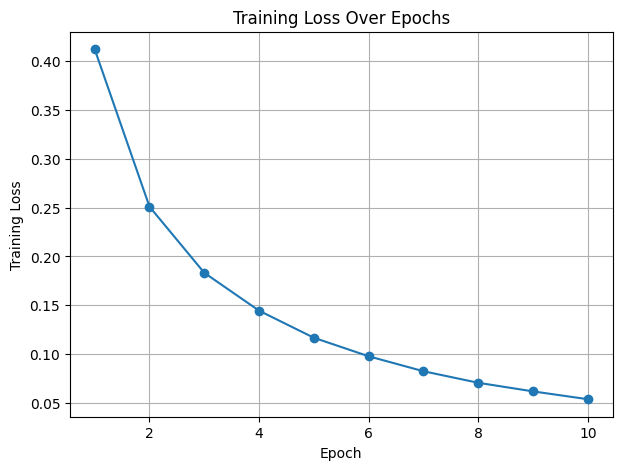

In [ ]:
# Plot training loss over epochs
plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

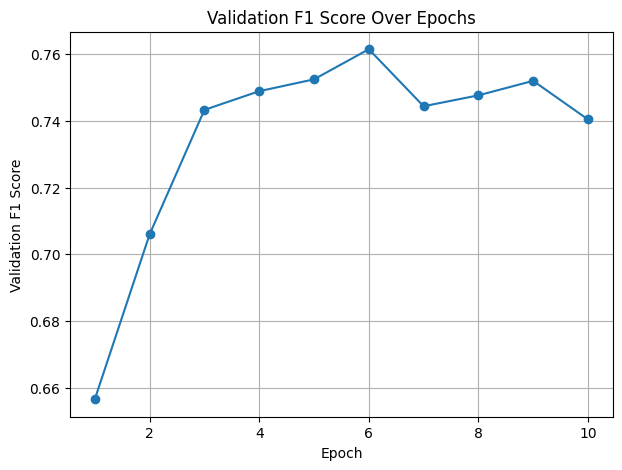

In [ ]:
# Plot validation F1 over epochs
plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation F1 Score")
plt.title("Validation F1 Score Over Epochs")
plt.grid(True)
plt.show()

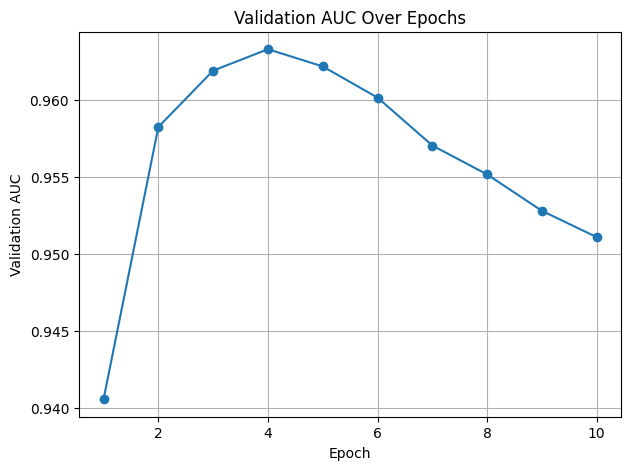

In [ ]:
# Plot validation AUC over epochs
plt.figure(figsize=(7, 5))
plt.plot(history_df["epoch"], history_df["val_auc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC Over Epochs")
plt.grid(True)
plt.show()

## Find Best Threshold


In [ ]:
# This function finds the threshold that gives the best F1 score
def find_best_threshold(loader):
    # Get validation probabilities and labels
    probs, labels = get_probs_and_labels(loader)

    # Start with the normal 0.5 threshold
    best_threshold = 0.5
    best_f1 = 0

    # Try thresholds from 0.05 to 0.95
    for threshold in np.arange(0.05, 0.96, 0.05):
        # Make clean/unclean predictions at this threshold
        preds = (probs >= threshold).astype(int)

        # Calculate F1 score
        f1 = f1_score(labels, preds, zero_division=0)

        # Keep the threshold if it improves F1
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    # Return the best threshold
    return best_threshold


# Load the best saved model before choosing the threshold
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Find best threshold on validation data
best_threshold = find_best_threshold(val_loader)

# Evaluate validation data with the chosen threshold
val_results = evaluate(val_loader, threshold=best_threshold)

print("Best threshold:", round(best_threshold, 2))
print("Validation results with best threshold:")
pd.DataFrame([val_results])


Best threshold: 0.75
Validation results with best threshold:


,threshold,auc,accuracy,precision,recall,f1,clean_correct,clean_called_unclean,unclean_called_clean,unclean_correct
0,0.75,0.963288,0.955444,0.824493,0.713713,0.765114,28177,493,929,2316


In [ ]:
# Compare validation baseline with neural network
baseline_val_results = majority_baseline(val_data["unclean"].values.astype(int))

nn_val_results = val_results.copy()
nn_val_results["model"] = "Neural Network"
nn_val_results["predicted_class"] = "threshold-based"

comparison_df = pd.DataFrame([
    baseline_val_results,
    nn_val_results
])

# Reorder columns to make the table easier to read
comparison_df = comparison_df[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc",
        "clean_correct",
        "clean_called_unclean",
        "unclean_called_clean",
        "unclean_correct"
    ]
]

comparison_df

,model,accuracy,precision,recall,f1,auc,clean_correct,clean_called_unclean,unclean_called_clean,unclean_correct
0,Majority Class Baseline,0.898324,0.000000,0.000000,0.000000,0.500000,28670,0,3245,0
1,Neural Network,0.955444,0.824493,0.713713,0.765114,0.963288,28177,493,929,2316


## Prepare Real Test Data


In [ ]:
# test_labels.csv has some rows with -1
# -1 means those rows should not be used for scoring
valid_test_labels = test_labels[
    (test_labels[label_cols] != -1).all(axis=1)
].copy()

# Build the same clean/unclean target for the real labeled test rows
valid_test_labels["label_count"] = valid_test_labels[label_cols].sum(axis=1)
valid_test_labels["unclean"] = (valid_test_labels["label_count"] > 0).astype(int)
valid_test_labels["clean"] = 1 - valid_test_labels["unclean"]

# Merge test comments with their clean/unclean labels
test_labeled_df = test_df.merge(
    valid_test_labels[["id", "clean", "unclean"]],
    on="id"
)

# Check test data size and balance
print("Real labeled test data:", test_labeled_df.shape)
print("Clean test comments:", test_labeled_df["clean"].sum())
print("Unclean test comments:", test_labeled_df["unclean"].sum())


Real labeled test data: (63978, 5)
Clean test comments: 57735
Unclean test comments: 6243


## Test Model


In [ ]:
# Create test dataset with real labels
test_dataset = CleanUncleanDataset(test_labeled_df)

# Create test loader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load the best saved model before testing
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Evaluate on test data using the best validation threshold
test_results = evaluate(test_loader, threshold=best_threshold)

# Print final test results
print("Test AUC:", round(test_results["auc"], 4))
print("Test Accuracy:", round(test_results["accuracy"], 4))
print("Test Precision:", round(test_results["precision"], 4))
print("Test Recall:", round(test_results["recall"], 4))
print("Test F1:", round(test_results["f1"], 4))

# Show all test results in a table
pd.DataFrame([test_results])


Test AUC: 0.9485
Test Accuracy: 0.9121
Test Precision: 0.5326
Test Recall: 0.8076
Test F1: 0.6419


,threshold,auc,accuracy,precision,recall,f1,clean_correct,clean_called_unclean,unclean_called_clean,unclean_correct
0,0.75,0.948475,0.912064,0.532587,0.807625,0.641884,53310,4425,1201,5042


### Confusion Matrix Explanation

- **Clean correctly predicted as clean**: the model correctly identified safe comments.
- **Clean predicted as unclean**: false positive. The model flagged a safe comment as toxic.
- **Unclean predicted as clean**: false negative. The model missed a toxic comment.
- **Unclean correctly predicted as unclean**: the model correctly detected toxic comments.

In [ ]:
# Import Rectangle from matplotlib.
# We use Rectangle to manually draw the four confusion matrix boxes.
import matplotlib.patches as patches


def plot_confusion_matrix_picture(
    results,
    title="Binary NN Test Confusion Matrix",
    save_path=None
):
    """
    This function creates a visual confusion matrix as an image.

    The function expects the results dictionary returned by the evaluate() function.
    That dictionary already contains the four confusion matrix values:

    clean_correct          = actual clean predicted as clean
    clean_called_unclean   = actual clean predicted as unclean
    unclean_called_clean   = actual unclean predicted as clean
    unclean_correct        = actual unclean predicted as unclean
    """

    # Get the four values from the evaluation results.
    # int() is used to make sure the values display as normal whole numbers.
    clean_correct = int(results["clean_correct"])
    clean_called_unclean = int(results["clean_called_unclean"])
    unclean_called_clean = int(results["unclean_called_clean"])
    unclean_correct = int(results["unclean_correct"])

    # Store the values in a 2x2 matrix layout.
    #
    # Row 1: actual clean comments
    # Row 2: actual unclean comments
    #
    # Column 1: predicted clean
    # Column 2: predicted unclean
    values = [
        [clean_correct, clean_called_unclean],
        [unclean_called_clean, unclean_correct]
    ]

    # Define colors for the cells.
    # Green cells are correct predictions.
    # Yellow and red cells are mistakes.
    green = "#e8f3e8"       # correct predictions
    yellow = "#fff2c9"      # false positives: clean predicted as unclean
    red = "#f8e6e3"         # false negatives: unclean predicted as clean
    border = "#aebdcc"      # border around the cells
    dark_blue = "#0b2545"   # title and numbers
    label_blue = "#1f4e79"  # row and column labels

    # Match each cell with a color.
    # Top-left and bottom-right are correct, so they are green.
    # Top-right is a false positive, so it is yellow.
    # Bottom-left is a false negative, so it is red.
    colors = [
        [green, yellow],
        [red, green]
    ]

    # Create the figure and drawing area.
    # figsize controls the size of the final image.
    fig, ax = plt.subplots(figsize=(12, 7))

    # Set the coordinate system for drawing.
    # These numbers give us a canvas from x=0 to x=10 and y=0 to y=7.
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 7)

    # Hide the normal chart axes because this is a custom diagram,
    # not a standard line chart or bar chart.
    ax.axis("off")

    # Add the main title at the top left.
    ax.text(
        0.7, 6.55,
        title,
        fontsize=26,
        fontweight="bold",
        color=dark_blue,
        ha="left",
        va="center"
    )

    # Define where the confusion matrix should start.
    # left and bottom control the position of the whole 2x2 matrix.
    left = 2.3
    bottom = 2.4

    # Define the size of each cell.
    cell_width = 2.7
    cell_height = 1.45

    # Add the first column label.
    ax.text(
        left + cell_width / 2,
        bottom + 2 * cell_height + 0.4,
        "Predicted clean",
        fontsize=16,
        fontweight="bold",
        color=label_blue,
        ha="center"
    )

    # Add the second column label.
    ax.text(
        left + 1.5 * cell_width,
        bottom + 2 * cell_height + 0.4,
        "Predicted unclean",
        fontsize=16,
        fontweight="bold",
        color=label_blue,
        ha="center"
    )

    # Add the first row label.
    ax.text(
        left - 0.6,
        bottom + 1.5 * cell_height,
        "Actual clean",
        fontsize=16,
        fontweight="bold",
        color=label_blue,
        ha="right",
        va="center"
    )

    # Add the second row label.
    ax.text(
        left - 0.6,
        bottom + 0.5 * cell_height,
        "Actual unclean",
        fontsize=16,
        fontweight="bold",
        color=label_blue,
        ha="right",
        va="center"
    )

    # Draw the four confusion matrix cells.
    # row controls whether we are drawing actual clean or actual unclean.
    # col controls whether we are drawing predicted clean or predicted unclean.
    for row in range(2):
        for col in range(2):

            # Calculate the x-position of the current cell.
            x = left + col * cell_width

            # Calculate the y-position of the current cell.
            # The expression (1 - row) is used because matplotlib draws from the bottom,
            # but confusion matrices are usually read from the top row first.
            y = bottom + (1 - row) * cell_height

            # Create one rectangular cell.
            rectangle = patches.Rectangle(
                (x, y),
                cell_width,
                cell_height,
                linewidth=2.5,
                edgecolor=border,
                facecolor=colors[row][col]
            )

            # Add the rectangle to the plot.
            ax.add_patch(rectangle)

            # Add the number in the center of the cell.
            # The :, format adds commas, for example 52830 becomes 52,830.
            ax.text(
                x + cell_width / 2,
                y + cell_height / 2,
                f"{values[row][col]:,}",
                fontsize=24,
                fontweight="bold",
                color=dark_blue,
                ha="center",
                va="center"
            )

    # Add a short explanation below the matrix.
    ax.text(
        0.7, 0.85,
        "Green cells are correct decisions. Yellow/red cells are review errors.",
        fontsize=14,
        color="#555555",
        ha="left"
    )

    # Save the image file if the user gives a save_path.
    # dpi=300 gives a high-quality image.
    # bbox_inches="tight" removes unnecessary whitespace around the figure.
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    # Display the image inside the notebook.
    plt.show()

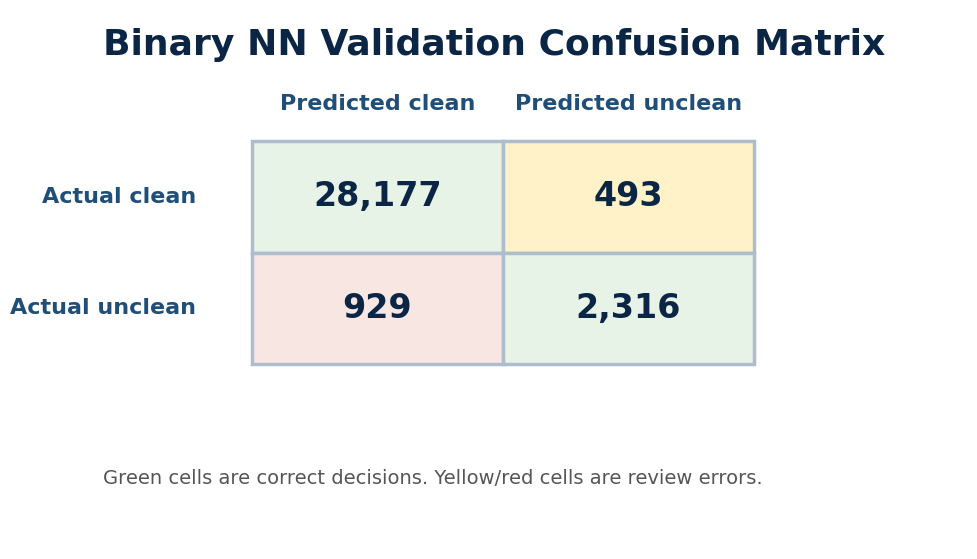

In [ ]:
plot_confusion_matrix_picture(
    val_results,
    title="Binary NN Validation Confusion Matrix",
    save_path="binary_nn_validation_confusion_matrix.png"
)

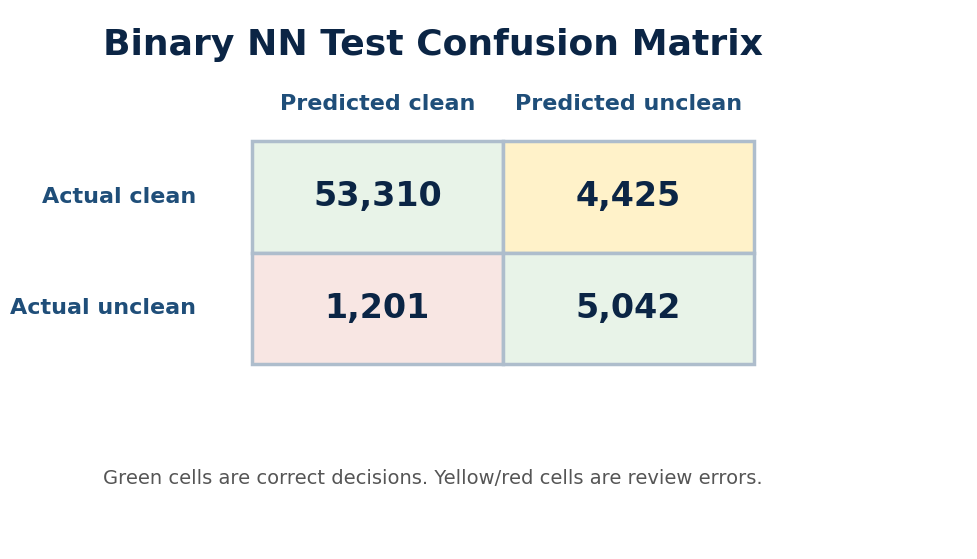

In [ ]:
plot_confusion_matrix_picture(
    test_results,
    title="Binary NN Test Confusion Matrix",
    save_path="binary_nn_test_confusion_matrix.png"
)

In [ ]:
# Compare test baseline with neural network
test_labels_binary = test_labeled_df["unclean"].values.astype(int)

baseline_test_results = majority_baseline(test_labels_binary)

nn_test_results = test_results.copy()
nn_test_results["model"] = "Neural Network"
nn_test_results["predicted_class"] = "threshold-based"

test_comparison_df = pd.DataFrame([
    baseline_test_results,
    nn_test_results
])

test_comparison_df = test_comparison_df[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc",
        "clean_correct",
        "clean_called_unclean",
        "unclean_called_clean",
        "unclean_correct"
    ]
]

test_comparison_df

,model,accuracy,precision,recall,f1,auc,clean_correct,clean_called_unclean,unclean_called_clean,unclean_correct
0,Majority Class Baseline,0.902420,0.000000,0.000000,0.000000,0.500000,57735,0,6243,0
1,Neural Network,0.912064,0.532587,0.807625,0.641884,0.948475,53310,4425,1201,5042


## Try One Comment


In [ ]:
# This function predicts clean or unclean for one new comment
def predict_clean_unclean(comment, threshold=best_threshold):
    # Clean the new comment the same way as training comments
    cleaned = clean_text(comment)

    # Convert the comment into word IDs
    encoded = encode_text(cleaned)

    # Add a batch dimension because the model expects a batch
    x = torch.tensor([encoded], dtype=torch.long).to(device)

    # Make prediction
    model.eval()
    with torch.no_grad():
        logits = model(x)
        prob_unclean = torch.sigmoid(logits).item()

    # Pick the final label
    predicted_label = "unclean" if prob_unclean >= threshold else "clean"

    # Return a small readable result
    return {
        "comment": comment,
        "prob_unclean": prob_unclean,
        "predicted_label": predicted_label
    }


# Example clean comment
predict_clean_unclean("Thank you for improving the article.")


{'comment': 'Thank you for improving the article.',
 'prob_unclean': 3.589929065128672e-06,
 'predicted_label': 'clean'}